In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import StandardScaler
from scdeepsim.ae import LightningAE
from scdeepsim.plot import compare_umap
from scdeepsim.quality import rf_discriminability, knn_discriminability

In [3]:
muris = sc.read_h5ad('../data/tabula_muris/all.h5ad')
muris.var_names_make_unique()
sc.pp.filter_cells(muris, min_genes=10)
sc.pp.filter_genes(muris, min_cells=2)
sc.pp.normalize_total(muris, target_sum=1e4)
sc.pp.log1p(muris)
muris_selected = muris.X.toarray()[np.random.choice(muris.n_obs, 20000, replace=False)]
muris_10k = muris_selected[:10000]
muris_control = muris_selected[10000:]

In [4]:
print(muris_10k.shape)
print(muris_control.shape)

(10000, 18996)
(10000, 18996)


In [5]:
baseline_samples = np.load('../data/comparisons/sim_muris_decoded.npy')
ddpm_samples = np.load('../data/samples/muris/decoded_ddpm_samples.npy')
quadratic_samples = np.load('../data/samples/muris/decoded_quadratic_ddim_samples.npy')
linear_samples = np.load('../data/samples/muris/decoded_linear_ddim_samples.npy')
cosine_samples = np.load('../data/samples/muris/decoded_cosine_ddim_samples.npy')

In [23]:
def plot_discriminability(aucs, accuracies, methods, title):

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].bar(methods, aucs, color='steelblue', alpha=0.7)
    axes[0].axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Random (0.5)')
    axes[0].set_ylabel('AUC-ROC', fontsize=12)
    axes[0].set_xlabel('Method', fontsize=12)
    axes[0].set_title('Discriminability: AUC-ROC', fontsize=14, fontweight='bold')
    axes[0].set_ylim([0, 1])
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)

    # Plot Accuracy
    axes[1].bar(methods, accuracies, color='coral', alpha=0.7)
    axes[1].axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Random (0.5)')
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_xlabel('Method', fontsize=12)
    axes[1].set_title('Discriminability: Accuracy', fontsize=14, fontweight='bold')
    axes[1].set_ylim([0, 1])
    axes[1].legend()
    axes[1].grid(axis='y', alpha=0.3)

    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Print numerical results
    print("\nDiscriminability Results:")
    print("-" * 50)
    for method, auc, acc in zip(methods, aucs, accuracies):
        print(f"{method:12s} | AUC: {auc:.4f} | Accuracy: {acc:.4f}")


In [ ]:
auc_control, acc_control = rf_discriminability(muris_10k, muris_control, n_estimators=10)
auc_baseline, acc_baseline = rf_discriminability(muris_10k, baseline_samples, n_estimators=10)
auc_ddpm, acc_ddpm = rf_discriminability(muris_10k, ddpm_samples, n_estimators=10)
auc_quadratic, acc_quadratic = rf_discriminability(muris_10k, quadratic_samples, n_estimators=10)
auc_linear, acc_linear = rf_discriminability(muris_10k, linear_samples, n_estimators=10)
auc_cosine, acc_cosine = rf_discriminability(muris_10k, cosine_samples, n_estimators=10)


methods = ['Control', 'Baseline', 'DDPM', 'Quadratic', 'Linear', 'Cosine']
aucs = [auc_control, auc_baseline, auc_ddpm, auc_quadratic, auc_linear, auc_cosine]
accuracies = [acc_control, acc_baseline, acc_ddpm, acc_quadratic, acc_linear, acc_cosine]

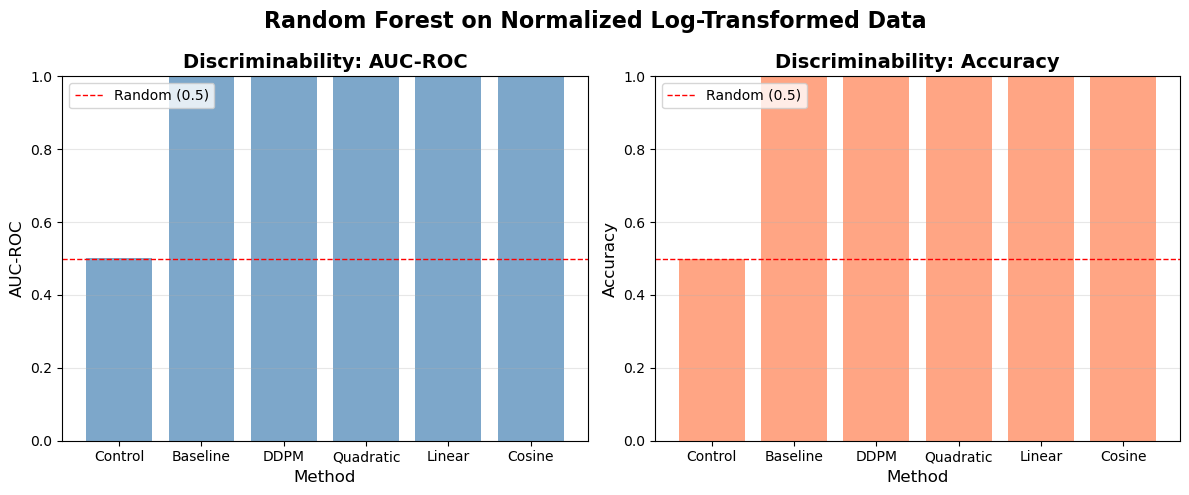


Discriminability Results:
--------------------------------------------------
Control      | AUC: 0.5024 | Accuracy: 0.4980
Baseline     | AUC: 1.0000 | Accuracy: 1.0000
DDPM         | AUC: 1.0000 | Accuracy: 1.0000
Quadratic    | AUC: 1.0000 | Accuracy: 1.0000
Linear       | AUC: 1.0000 | Accuracy: 1.0000
Cosine       | AUC: 1.0000 | Accuracy: 1.0000


In [24]:
plot_discriminability(aucs, accuracies, methods, 'Random Forest on Normalized Log-Transformed Data')

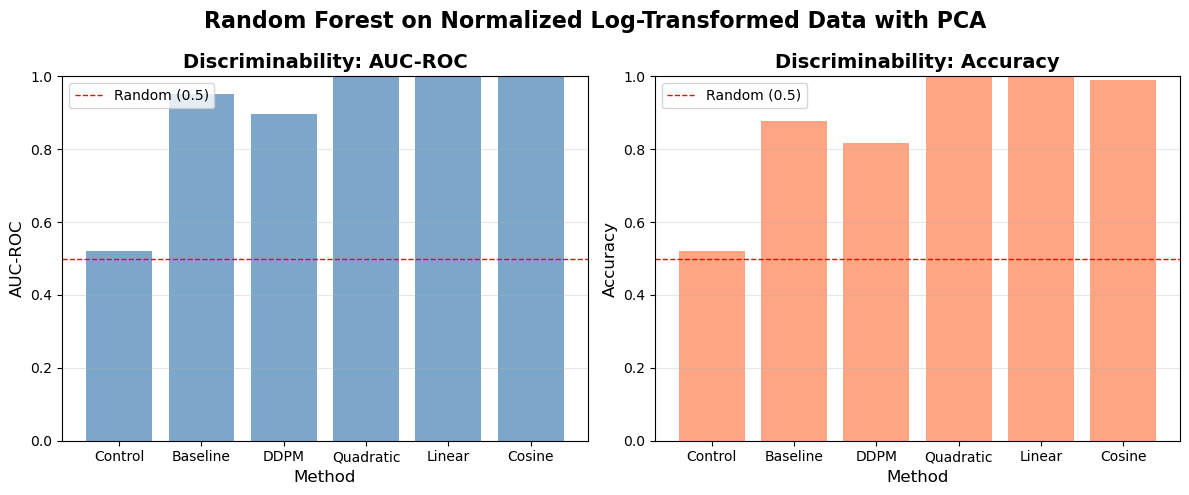


Discriminability Results:
--------------------------------------------------
Control      | AUC: 0.5197 | Accuracy: 0.5202
Baseline     | AUC: 0.9508 | Accuracy: 0.8772
DDPM         | AUC: 0.8959 | Accuracy: 0.8163
Quadratic    | AUC: 1.0000 | Accuracy: 1.0000
Linear       | AUC: 1.0000 | Accuracy: 1.0000
Cosine       | AUC: 0.9986 | Accuracy: 0.9890


In [25]:
n_estimators = 100
pca_components = 50
auc_control, acc_control = rf_discriminability(muris_10k, muris_control, n_estimators=n_estimators, pca_components=pca_components)
auc_baseline, acc_baseline = rf_discriminability(muris_10k, baseline_samples, n_estimators=n_estimators, pca_components=pca_components)
auc_ddpm, acc_ddpm = rf_discriminability(muris_10k, ddpm_samples, n_estimators=n_estimators, pca_components=pca_components)
auc_quadratic, acc_quadratic = rf_discriminability(muris_10k, quadratic_samples, n_estimators=n_estimators, pca_components=pca_components)
auc_linear, acc_linear = rf_discriminability(muris_10k, linear_samples, n_estimators=n_estimators, pca_components=pca_components)
auc_cosine, acc_cosine = rf_discriminability(muris_10k, cosine_samples, n_estimators=n_estimators, pca_components=pca_components)

methods = ['Control', 'Baseline', 'DDPM', 'Quadratic', 'Linear', 'Cosine']
aucs = [auc_control, auc_baseline, auc_ddpm, auc_quadratic, auc_linear, auc_cosine]
accuracies = [acc_control, acc_baseline, acc_ddpm, acc_quadratic, acc_linear, acc_cosine]

plot_discriminability(aucs, accuracies, methods, 'Random Forest on Normalized Log-Transformed Data with PCA')

PCA completed with 50 components
PCA completed with 50 components
PCA completed with 50 components
PCA completed with 50 components
PCA completed with 50 components
PCA completed with 50 components


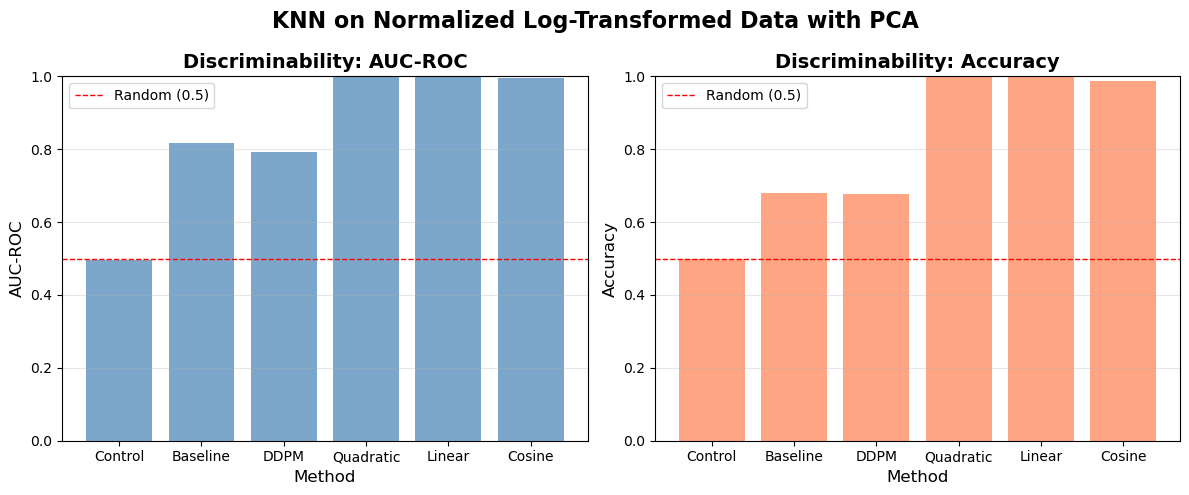


Discriminability Results:
--------------------------------------------------
Control      | AUC: 0.4962 | Accuracy: 0.4985
Baseline     | AUC: 0.8160 | Accuracy: 0.6797
DDPM         | AUC: 0.7916 | Accuracy: 0.6770
Quadratic    | AUC: 1.0000 | Accuracy: 1.0000
Linear       | AUC: 1.0000 | Accuracy: 1.0000
Cosine       | AUC: 0.9947 | Accuracy: 0.9878


In [26]:
n_neighbors = 5
pca_components = 50
auc_control, acc_control = knn_discriminability(muris_10k, muris_control, n_neighbors=n_neighbors, pca_components=pca_components)
auc_baseline, acc_baseline = knn_discriminability(muris_10k, baseline_samples, n_neighbors=n_neighbors, pca_components=pca_components)
auc_ddpm, acc_ddpm = knn_discriminability(muris_10k, ddpm_samples, n_neighbors=n_neighbors, pca_components=pca_components)
auc_quadratic, acc_quadratic = knn_discriminability(muris_10k, quadratic_samples, n_neighbors=n_neighbors, pca_components=pca_components)
auc_linear, acc_linear = knn_discriminability(muris_10k, linear_samples, n_neighbors=n_neighbors, pca_components=pca_components)
auc_cosine, acc_cosine = knn_discriminability(muris_10k, cosine_samples, n_neighbors=n_neighbors, pca_components=pca_components)

methods = ['Control', 'Baseline', 'DDPM', 'Quadratic', 'Linear', 'Cosine']
aucs = [auc_control, auc_baseline, auc_ddpm, auc_quadratic, auc_linear, auc_cosine]
accuracies = [acc_control, acc_baseline, acc_ddpm, acc_quadratic, acc_linear, acc_cosine]

plot_discriminability(aucs, accuracies, methods, 'KNN on Normalized Log-Transformed Data with PCA')


In [27]:
ae_path = "checkpoints/muris/trained_ae.ckpt"
ae = LightningAE.load_from_checkpoint(ae_path)
device = ae.device

ae.eval()
with torch.no_grad():
    latent_muris_10k = ae.encode(torch.tensor(muris_10k).to(device=device, dtype=torch.float32))
    latent_muris_control = ae.encode(torch.tensor(muris_control).to(device=device, dtype=torch.float32))
    baseline_latent_samples = ae.encode(torch.tensor(baseline_samples).to(device=device, dtype=torch.float32))
    
standard_scaler = StandardScaler()
scaled_latent_muris_10k = standard_scaler.fit_transform(latent_muris_10k.cpu().numpy())
scaled_latent_muris_control = standard_scaler.fit_transform(latent_muris_control.cpu().numpy())
scaled_baseline_latent_samples = standard_scaler.fit_transform(baseline_latent_samples.cpu().numpy())

ddpm_latent_samples = np.load('../data/samples/muris/standardized_latent_ddpm_samples.npy')
quadratic_latent_samples = np.load('../data/samples/muris/standardized_latent_samples_quadratic.npy')
linear_latent_samples = np.load('../data/samples/muris/standardized_latent_samples_linear.npy')
cosine_latent_samples = np.load('../data/samples/muris/standardized_latent_samples_cosine.npy')

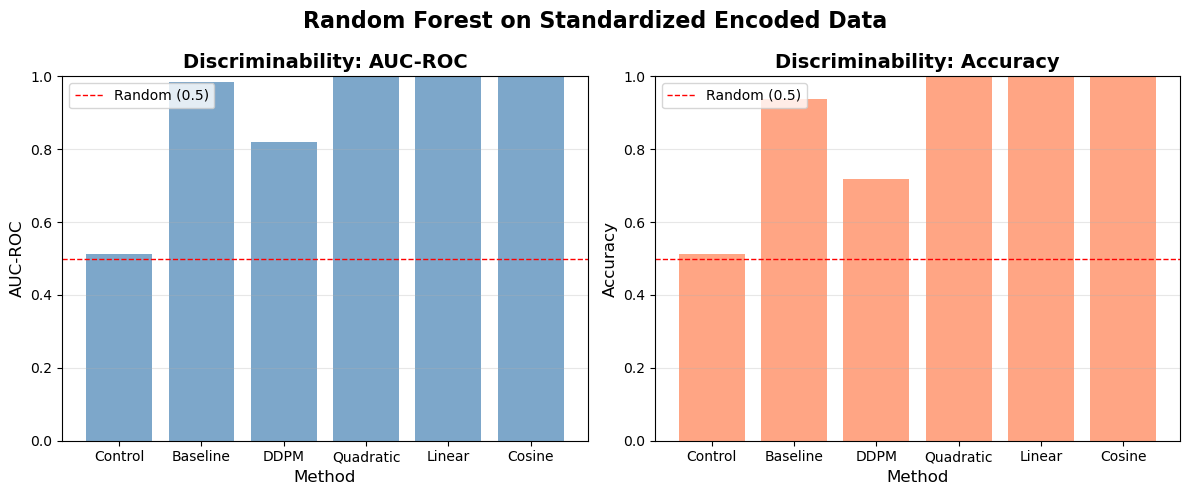


Discriminability Results:
--------------------------------------------------
Control      | AUC: 0.5129 | Accuracy: 0.5125
Baseline     | AUC: 0.9844 | Accuracy: 0.9385
DDPM         | AUC: 0.8190 | Accuracy: 0.7173
Quadratic    | AUC: 1.0000 | Accuracy: 1.0000
Linear       | AUC: 1.0000 | Accuracy: 1.0000
Cosine       | AUC: 0.9994 | Accuracy: 0.9972


In [28]:
n_estimators = 100
auc_control, acc_control = rf_discriminability(scaled_latent_muris_10k, scaled_latent_muris_control, n_estimators=n_estimators)
auc_baseline, acc_baseline = rf_discriminability(scaled_latent_muris_10k, scaled_baseline_latent_samples, n_estimators=n_estimators)
auc_ddpm, acc_ddpm = rf_discriminability(scaled_latent_muris_10k, ddpm_latent_samples, n_estimators=n_estimators)
auc_quadratic, acc_quadratic = rf_discriminability(scaled_latent_muris_10k, quadratic_latent_samples, n_estimators=n_estimators)
auc_linear, acc_linear = rf_discriminability(scaled_latent_muris_10k, linear_latent_samples, n_estimators=n_estimators)
auc_cosine, acc_cosine = rf_discriminability(scaled_latent_muris_10k, cosine_latent_samples, n_estimators=n_estimators)

methods = ['Control', 'Baseline', 'DDPM', 'Quadratic', 'Linear', 'Cosine']
aucs = [auc_control, auc_baseline, auc_ddpm, auc_quadratic, auc_linear, auc_cosine]
accuracies = [acc_control, acc_baseline, acc_ddpm, acc_quadratic, acc_linear, acc_cosine]

plot_discriminability(aucs, accuracies, methods, 'Random Forest on Standardized Encoded Data')

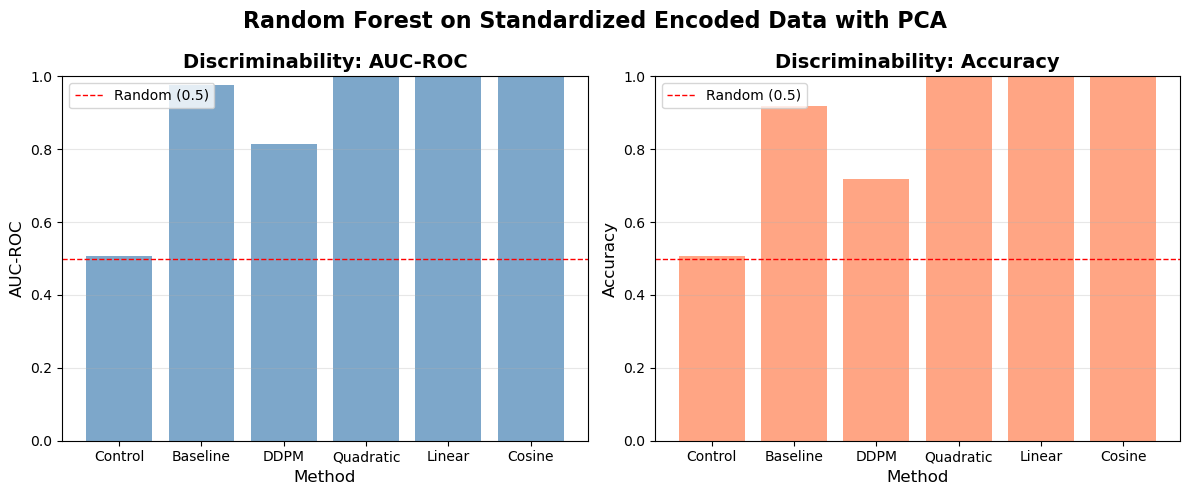


Discriminability Results:
--------------------------------------------------
Control      | AUC: 0.5077 | Accuracy: 0.5078
Baseline     | AUC: 0.9761 | Accuracy: 0.9193
DDPM         | AUC: 0.8142 | Accuracy: 0.7188
Quadratic    | AUC: 1.0000 | Accuracy: 1.0000
Linear       | AUC: 1.0000 | Accuracy: 1.0000
Cosine       | AUC: 0.9995 | Accuracy: 0.9970


In [29]:
n_estimators = 100
pca_components = 50
auc_control, acc_control = rf_discriminability(scaled_latent_muris_10k, scaled_latent_muris_control, n_estimators=n_estimators, pca_components=pca_components)
auc_baseline, acc_baseline = rf_discriminability(scaled_latent_muris_10k, scaled_baseline_latent_samples, n_estimators=n_estimators, pca_components=pca_components)
auc_ddpm, acc_ddpm = rf_discriminability(scaled_latent_muris_10k, ddpm_latent_samples, n_estimators=n_estimators, pca_components=pca_components)
auc_quadratic, acc_quadratic = rf_discriminability(scaled_latent_muris_10k, quadratic_latent_samples, n_estimators=n_estimators, pca_components=pca_components)
auc_linear, acc_linear = rf_discriminability(scaled_latent_muris_10k, linear_latent_samples, n_estimators=n_estimators, pca_components=pca_components)
auc_cosine, acc_cosine = rf_discriminability(scaled_latent_muris_10k, cosine_latent_samples, n_estimators=n_estimators, pca_components=pca_components)

methods = ['Control', 'Baseline', 'DDPM', 'Quadratic', 'Linear', 'Cosine']
aucs = [auc_control, auc_baseline, auc_ddpm, auc_quadratic, auc_linear, auc_cosine]
accuracies = [acc_control, acc_baseline, acc_ddpm, acc_quadratic, acc_linear, acc_cosine]

plot_discriminability(aucs, accuracies, methods, 'Random Forest on Standardized Encoded Data with PCA')

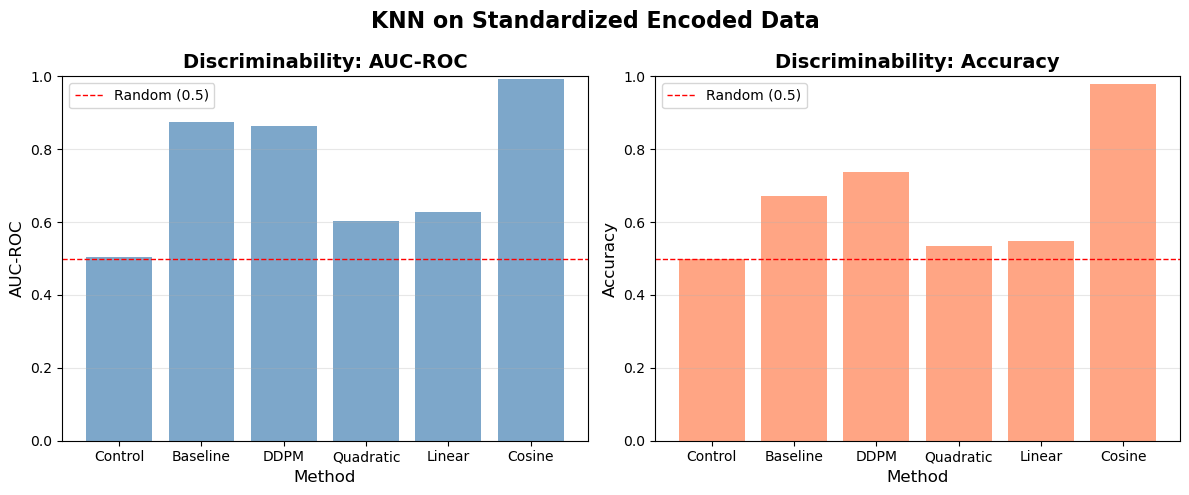


Discriminability Results:
--------------------------------------------------
Control      | AUC: 0.5036 | Accuracy: 0.4993
Baseline     | AUC: 0.8753 | Accuracy: 0.6713
DDPM         | AUC: 0.8648 | Accuracy: 0.7372
Quadratic    | AUC: 0.6025 | Accuracy: 0.5343
Linear       | AUC: 0.6275 | Accuracy: 0.5477
Cosine       | AUC: 0.9937 | Accuracy: 0.9792


In [30]:
n_neighbors = 10
auc_control, acc_control = knn_discriminability(scaled_latent_muris_10k, scaled_latent_muris_control, n_neighbors=n_neighbors)
auc_baseline, acc_baseline = knn_discriminability(scaled_latent_muris_10k, scaled_baseline_latent_samples, n_neighbors=n_neighbors)
auc_ddpm, acc_ddpm = knn_discriminability(scaled_latent_muris_10k, ddpm_latent_samples, n_neighbors=n_neighbors)
auc_quadratic, acc_quadratic = knn_discriminability(scaled_latent_muris_10k, quadratic_latent_samples, n_neighbors=n_neighbors)
auc_linear, acc_linear = knn_discriminability(scaled_latent_muris_10k, linear_latent_samples, n_neighbors=n_neighbors)
auc_cosine, acc_cosine = knn_discriminability(scaled_latent_muris_10k, cosine_latent_samples, n_neighbors=n_neighbors)


methods = ['Control', 'Baseline', 'DDPM', 'Quadratic', 'Linear', 'Cosine']
aucs = [auc_control, auc_baseline, auc_ddpm, auc_quadratic, auc_linear, auc_cosine]
accuracies = [acc_control, acc_baseline, acc_ddpm, acc_quadratic, acc_linear, acc_cosine]

plot_discriminability(aucs, accuracies, methods, 'KNN on Standardized Encoded Data')